# **Cyclistic Bike Share Analysis**

## **Google Data Analytics Capstone Project**

### **Business Problem**

Cyclistic is a fictional bike-sharing company in Chicago. The marketing team wants to increase annual memberships because annual members are more profitable than casual riders.

The objective of this project is to analyze historical bike trip data to identify behavioral differences between annual members and casual riders. Based on the findings, business recommendations will be provided to help convert casual riders into annual members.

---

## Business Task

Analyze Cyclistic's historical trip data to answer the following business question:

**How do annual members and casual riders use Cyclistic bikes differently?**

---

## Tools Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib

---

## Expected Deliverables

- Data Cleaning
- Exploratory Data Analysis
- Business Insights
- Data Visualization
- Recommendations

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from google.colab import files
from google.colab import drive

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Display all rows (optional)
pd.set_option("display.max_rows", 100)

# Load Dataset

The dataset is uploaded from the local computer using Google Colab.

The dataset contains ride-level information such as:

- Ride ID
- Bike Type
- Start Time
- End Time
- Station Information
- Latitude & Longitude
- Rider Type (Member / Casual)

In [ ]:
# ============================================================
# Read Dataset from Google Drive
# ============================================================

file_path = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Raw/Divvy_Trips_2020_Q1.csv"

df = pd.read_csv(file_path)

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


# Dataset Overview

Before cleaning the data, we first inspect its structure, dimensions, column names, and sample records.

In [ ]:
# ============================================================
# First Five Rows
# ============================================================

df.head()

# ============================================================
# Last Five Rows
# ============================================================

df.tail()

# ============================================================
# Dataset Shape
# ============================================================

rows, columns = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {columns}")

# ============================================================
# Column Names
# ============================================================

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# ============================================================
# Dataset Information
# ============================================================

df.info()

# ============================================================
# Summary Statistics
# ============================================================

df.describe(include="all")


# ============================================================
# Missing Values
# ============================================================

missing = df.isnull().sum()

missing = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": np.round((missing.values / len(df)) * 100, 2)
})

missing.sort_values(by="Missing Values", ascending=False)


# ============================================================
# Duplicate Rows
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")


# ============================================================
# Unique Values
# ============================================================

df.nunique()




Number of Rows    : 426,887
Number of Columns : 13
1. ride_id
2. rideable_type
3. started_at
4. ended_at
5. start_station_name
6. start_station_id
7. end_station_name
8. end_station_id
9. start_lat
10. start_lng
11. end_lat
12. end_lng
13. member_casual
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non

,0
ride_id,426887
rideable_type,1
started_at,399265
ended_at,399532
start_station_name,607
start_station_id,607
end_station_name,602
end_station_id,602
start_lat,518
start_lng,484


# Initial Observations

Write your observations after running the above code.

Example:

- Dataset contains _____ rows.
- Dataset contains _____ columns.
- Some columns contain missing values.
- Ride IDs appear to be unique.
- Date columns need to be converted into datetime format.
- Further data cleaning is required before analysis.

# **Data Cleaning**

***How did you clean your data before analysis?***

Data cleaning is a critical step before performing any analysis.

The objectives of this section are:

- Convert date columns into datetime format
- Check and remove duplicate records
- Remove invalid rides
- Handle missing values
- Create ride duration
- Verify data quality
- Prepare the dataset for exploratory data analysis

In [ ]:
# ============================================================
# Create a Copy of the Original Dataset
# ============================================================

df_clean = df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


In [ ]:
# ============================================================
# Check Data Types
# ============================================================

df_clean.dtypes

,0
ride_id,object
rideable_type,object
started_at,object
ended_at,object
start_station_name,object
start_station_id,int64
end_station_name,object
end_station_id,float64
start_lat,float64
start_lng,float64


In [ ]:
# ============================================================
# Convert Date Columns
# ============================================================

df_clean["started_at"] = pd.to_datetime(df_clean["started_at"])

df_clean["ended_at"] = pd.to_datetime(df_clean["ended_at"])

print("Datetime conversion completed.")

Datetime conversion completed.


In [ ]:
# ============================================================
# Verify Datetime Conversion
# ============================================================

df_clean[["started_at", "ended_at"]].dtypes

,0
started_at,datetime64[ns]
ended_at,datetime64[ns]


## Create Ride Duration

Ride duration is one of the most important variables in this analysis.

It is calculated as:

Ride Duration = End Time − Start Time

The duration is stored in minutes for easier interpretation.

In [ ]:
# ============================================================
# Create Ride Duration
# ============================================================

df_clean["ride_length"] = (
    df_clean["ended_at"] -
    df_clean["started_at"]
).dt.total_seconds() / 60

df_clean["ride_length"].head()

,ride_length
0,7.516667
1,3.716667
2,2.850000
3,8.816667
4,5.533333


In [ ]:
# ============================================================
# Ride Duration Summary
# ============================================================

df_clean["ride_length"].describe()

,ride_length
count,426887.000000
mean,22.115105
std,619.041546
min,-9.200000
25%,5.483333
50%,9.166667
75%,15.816667
max,156450.400000


## Remove Invalid Ride Durations

Some rides may have:

- Zero duration
- Negative duration
- Extremely long durations due to system errors

These records should be removed.

In [ ]:
# ============================================================
# Invalid Ride Durations
# ============================================================

invalid = df_clean[df_clean["ride_length"] <= 0]

print("Invalid rides:", len(invalid))

Invalid rides: 210


In [ ]:
# ============================================================
# Remove Invalid Rides
# ============================================================

before = len(df_clean)

df_clean = df_clean[df_clean["ride_length"] > 0]

after = len(df_clean)

print(f"Rows Removed : {before-after}")
print(f"Rows Remaining : {after}")

Rows Removed : 210
Rows Remaining : 426677


In [ ]:
# ============================================================
# Remove Duplicate Ride IDs
# ============================================================

before = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="ride_id")

after = len(df_clean)

print(f"Duplicate Rows Removed : {before-after}")

Duplicate Rows Removed : 0


## Missing Value Analysis

Instead of immediately deleting missing values, we first inspect them to determine whether they are meaningful or acceptable.

In [ ]:
# ============================================================
# Missing Values
# ============================================================

missing = (
    df_clean.isnull()
    .sum()
    .reset_index()
)

missing.columns = [
    "Column",
    "Missing Values"
]

missing["Percentage"] = (
    missing["Missing Values"] /
    len(df_clean) *
    100
).round(2)

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Column,Missing Values,Percentage
0,ride_id,0,0.0
1,rideable_type,0,0.0
2,started_at,0,0.0
3,ended_at,0,0.0
4,start_station_name,0,0.0
5,start_station_id,0,0.0
6,end_station_name,0,0.0
7,end_station_id,0,0.0
8,start_lat,0,0.0
9,start_lng,0,0.0


### Observation

Station names and station IDs may contain missing values because some rides start or end outside docking stations or due to data collection limitations.

Since these columns are not required for ride duration analysis, the missing values will be retained unless they affect later analyses.

In [ ]:
# ============================================================
# Remaining Null Values
# ============================================================

df_clean.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,0
end_station_id,0
start_lat,0
start_lng,0


In [ ]:
# ============================================================
# Dataset Shape After Cleaning
# ============================================================

print("Rows :", df_clean.shape[0])

print("Columns :", df_clean.shape[1])

Rows : 426677
Columns : 14


In [ ]:
# ============================================================
# Save Clean Dataset
# ============================================================

output_path = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Clean dataset saved successfully!")

print(output_path)

Clean dataset saved successfully!
/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_clean.csv


# Data Cleaning Summary

The following cleaning steps were performed:

- Converted date columns to datetime format.
- Created ride duration in minutes.
- Removed rides with zero or negative duration.
- Removed duplicate ride IDs.
- Reviewed missing values.
- Saved the cleaned dataset for further analysis.

The dataset is now ready for feature engineering and exploratory data analysis.

# Feature Engineering

Feature engineering is the process of creating new variables from existing data.

These new features help identify rider behavior patterns and answer business questions more effectively.

The following features will be created:

- Ride Duration (Hours)
- Year
- Month Number
- Month Name
- Quarter
- Week Number
- Day Number
- Day Name
- Hour
- Minute
- Weekend Indicator
- Time of Day
- Season
- Rush Hour

In [ ]:
# ============================================================
# Ride Duration in Hours
# ============================================================

df_clean["ride_length_hours"] = df_clean["ride_length"] / 60

df_clean["ride_length_hours"].head()

,ride_length_hours
0,0.125278
1,0.061944
2,0.047500
3,0.146944
4,0.092222


In [ ]:
# ============================================================
# Date Features
# ============================================================

df_clean["year"] = df_clean["started_at"].dt.year

df_clean["month"] = df_clean["started_at"].dt.month_name()

df_clean["month_number"] = df_clean["started_at"].dt.month

df_clean["quarter"] = df_clean["started_at"].dt.quarter

df_clean["week_number"] = df_clean["started_at"].dt.isocalendar().week.astype(int)

df_clean["day"] = df_clean["started_at"].dt.day

df_clean["day_name"] = df_clean["started_at"].dt.day_name()

print("Date features created successfully.")


# ============================================================
# Time Features
# ============================================================

df_clean["hour"] = df_clean["started_at"].dt.hour

df_clean["minute"] = df_clean["started_at"].dt.minute

print("Time features created successfully.")


# ============================================================
# Time Features
# ============================================================

df_clean["hour"] = df_clean["started_at"].dt.hour

df_clean["minute"] = df_clean["started_at"].dt.minute

print("Time features created successfully.")

# ============================================================
# Weekend Indicator
# ============================================================

df_clean["is_weekend"] = df_clean["day_name"].isin([
    "Saturday",
    "Sunday"
])

df_clean["is_weekend"] = df_clean["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

df_clean["is_weekend"].value_counts()


# ============================================================
# Time of Day
# ============================================================

def get_time_of_day(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


df_clean["time_of_day"] = df_clean["hour"].apply(get_time_of_day)

df_clean["time_of_day"].value_counts()


# ============================================================
# Season
# ============================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df_clean["season"] = df_clean["month_number"].apply(get_season)

df_clean["season"].value_counts()


# ============================================================
# Rush Hour
# ============================================================

def rush_hour(hour):

    if 7 <= hour <= 9:
        return "Morning Rush"

    elif 16 <= hour <= 18:
        return "Evening Rush"

    else:
        return "Non Rush"


df_clean["rush_hour"] = df_clean["hour"].apply(rush_hour)

df_clean["rush_hour"].value_counts()


# ============================================================
# Sort Month and Day Correctly
# ============================================================

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

df_clean["month"] = pd.Categorical(
    df_clean["month"],
    categories=month_order,
    ordered=True
)

df_clean["day_name"] = pd.Categorical(
    df_clean["day_name"],
    categories=day_order,
    ordered=True
)

print("Month and Day ordering completed.")



# ============================================================
# View Engineered Features
# ============================================================

new_columns = [
    "ride_length",
    "ride_length_hours",
    "year",
    "month",
    "quarter",
    "week_number",
    "day_name",
    "hour",
    "time_of_day",
    "season",
    "rush_hour",
    "is_weekend"
]

df_clean[new_columns].head(10)


# ============================================================
# Dataset Information After Feature Engineering
# ============================================================

print("Rows :", df_clean.shape[0])

print("Columns :", df_clean.shape[1])

df_clean.info()



# ============================================================
# Save Dataset with Engineered Features
# ============================================================

output_path = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/cyclistic_featured.csv"

df_clean.to_csv(output_path, index=False)

print("Feature engineered dataset saved successfully.")
print(output_path)





Date features created successfully.
Time features created successfully.
Time features created successfully.
Month and Day ordering completed.
Rows : 426677
Columns : 28
<class 'pandas.core.frame.DataFrame'>
Index: 426677 entries, 0 to 426886
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             426677 non-null  object        
 1   rideable_type       426677 non-null  object        
 2   started_at          426677 non-null  datetime64[ns]
 3   ended_at            426677 non-null  datetime64[ns]
 4   start_station_name  426677 non-null  object        
 5   start_station_id    426677 non-null  int64         
 6   end_station_name    426677 non-null  object        
 7   end_station_id      426677 non-null  float64       
 8   start_lat           426677 non-null  float64       
 9   start_lng           426677 non-null  float64       
 10  end_lat             426677 non-null 

# Feature Engineering Summary

The following features were successfully created:

- Ride Duration (Minutes & Hours)
- Year
- Month Number
- Month Name
- Quarter
- Week Number
- Day Name
- Hour
- Weekend Indicator
- Time of Day
- Season
- Rush Hour

These engineered variables provide additional context for analyzing riding behavior and will be used during exploratory data analysis.

# **Exploratory Data Analysis (EDA)**

***How do annual members and casual riders use Cyclistic bikes differently?***

The objective of this section is to understand how annual members and casual riders differ in their bike usage.

Key questions:
- Who uses Cyclistic bikes more?
- Which bike types are most popular?
- How long are rides?
- Which days and months are busiest?
- When do people ride the most?
- How do riding patterns differ between members and casual riders?

In [ ]:
# ============================================================
# Overall Dataset Summary
# ============================================================

print("="*50)
print("CYCLISTIC DATASET SUMMARY")
print("="*50)

print(f"Total Rides          : {len(df_clean):,}")
print(f"Members              : {(df_clean['member_casual']=='member').sum():,}")
print(f"Casual Riders        : {(df_clean['member_casual']=='casual').sum():,}")

print(f"\nAverage Ride Length  : {df_clean['ride_length'].mean():.2f} minutes")
print(f"Median Ride Length   : {df_clean['ride_length'].median():.2f} minutes")
print(f"Maximum Ride Length  : {df_clean['ride_length'].max():.2f} minutes")
print(f"Minimum Ride Length  : {df_clean['ride_length'].min():.2f} minutes")

CYCLISTIC DATASET SUMMARY
Total Rides          : 426,677
Members              : 378,407
Casual Riders        : 48,270

Average Ride Length  : 22.13 minutes
Median Ride Length   : 9.17 minutes
Maximum Ride Length  : 156450.40 minutes
Minimum Ride Length  : 0.02 minutes


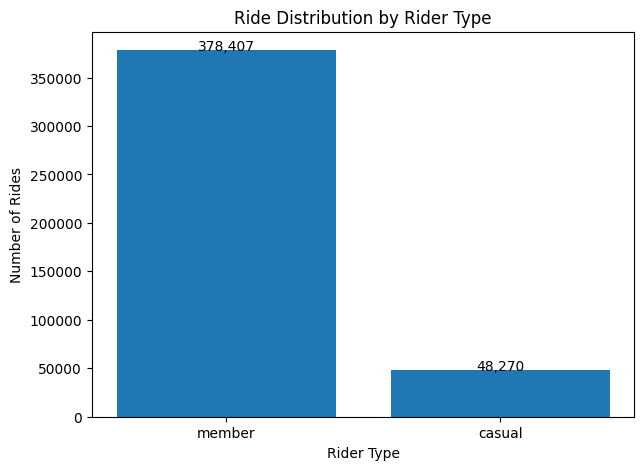

In [ ]:
# ============================================================
# Rider Type Distribution
# ============================================================

member_counts = df_clean["member_casual"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(member_counts.index,
        member_counts.values)

plt.title("Ride Distribution by Rider Type")

plt.xlabel("Rider Type")

plt.ylabel("Number of Rides")

for i,v in enumerate(member_counts.values):
    plt.text(i,v,f"{v:,}",ha='center')

plt.show()

### Business Insight

This chart shows the proportion of rides taken by annual members and casual riders.

This helps Cyclistic understand which customer segment contributes the most rides and where marketing efforts should focus.

In [ ]:
# ============================================================
# Bike Type Usage
# ============================================================

bike_usage = pd.crosstab(
    df_clean["rideable_type"],
    df_clean["member_casual"]
)

bike_usage

member_casual,casual,member
rideable_type,,
docked_bike,48270,378407


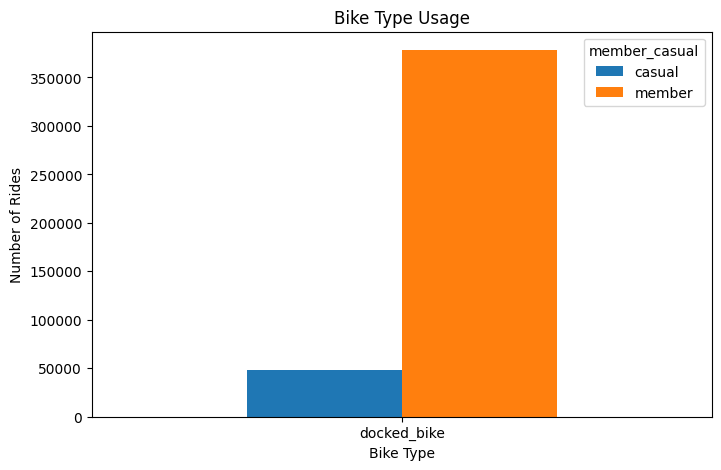

In [ ]:
bike_usage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Bike Type Usage")

plt.xlabel("Bike Type")

plt.ylabel("Number of Rides")

plt.xticks(rotation=0)

plt.show()

### Business Insight

This visualization compares the popularity of different bike types between annual members and casual riders.

It helps identify customer preferences for each bike type.

In [ ]:
# ============================================================
# Average Ride Duration
# ============================================================

avg_duration = (
    df_clean
    .groupby("member_casual")["ride_length"]
    .mean()
    .sort_values()
)

avg_duration

,ride_length
member_casual,
member,12.677113
casual,96.200077


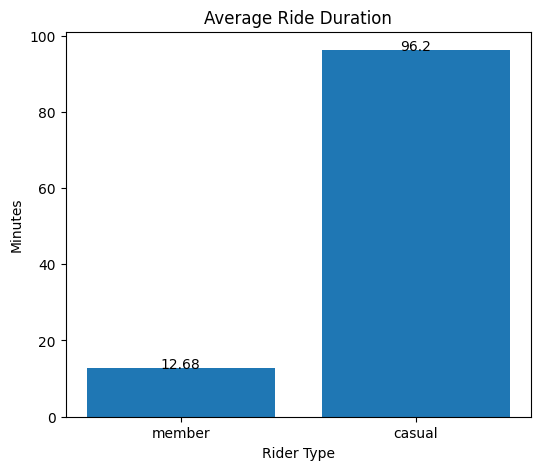

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(avg_duration.index,
        avg_duration.values)

plt.title("Average Ride Duration")

plt.xlabel("Rider Type")

plt.ylabel("Minutes")

for i,v in enumerate(avg_duration.values):
    plt.text(i,v,round(v,2),ha='center')

plt.show()

### Business Insight

Comparing average ride duration helps determine whether members primarily use bikes for commuting while casual riders tend to use them for leisure trips.

In [ ]:
monthly = (
    df_clean
    .groupby(["month","member_casual"])
    .size()
    .unstack()
)

monthly

member_casual,casual,member
month,,
January,7785,136099
February,12860,126715
March,27625,115593
April,0,0
May,0,0
June,0,0
July,0,0
August,0,0
September,0,0


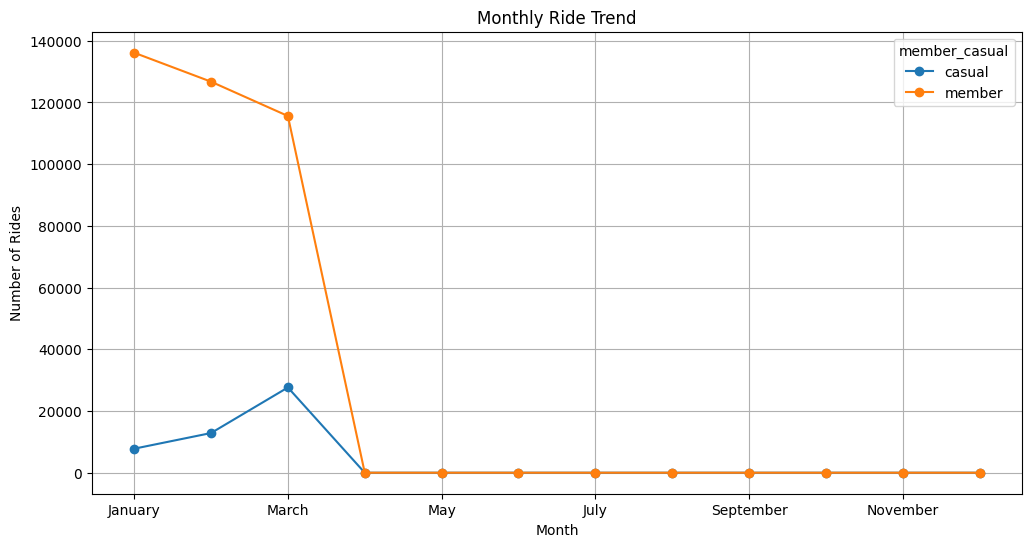

In [ ]:
monthly.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Ride Trend")

plt.xlabel("Month")

plt.ylabel("Number of Rides")

plt.grid(True)

plt.show()

### Business Insight

Monthly trends help identify seasonal riding behavior and determine when marketing campaigns should be launched.

In [ ]:
day_analysis = (
    df_clean
    .groupby(["day_name","member_casual"])
    .size()
    .unstack()
)

day_analysis

member_casual,casual,member
day_name,,
Monday,4802,61923
Tuesday,5244,69697
Wednesday,5874,63978
Thursday,4851,61245
Friday,5133,55496
Saturday,7480,30104
Sunday,14886,35964


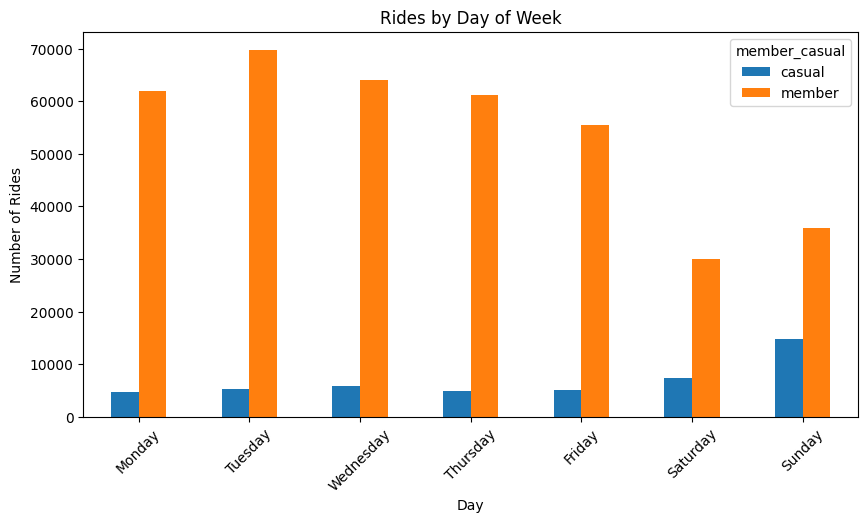

In [ ]:
day_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Rides by Day of Week")

plt.xlabel("Day")

plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

### Business Insight

Members often ride during weekdays, while casual riders may be more active on weekends. This information is valuable for planning targeted promotions.

In [ ]:
hourly = (
    df_clean
    .groupby(["hour","member_casual"])
    .size()
    .unstack()
)

hourly.head()

member_casual,casual,member
hour,,
0,312,1416
1,224,842
2,137,515
3,101,378
4,58,1028


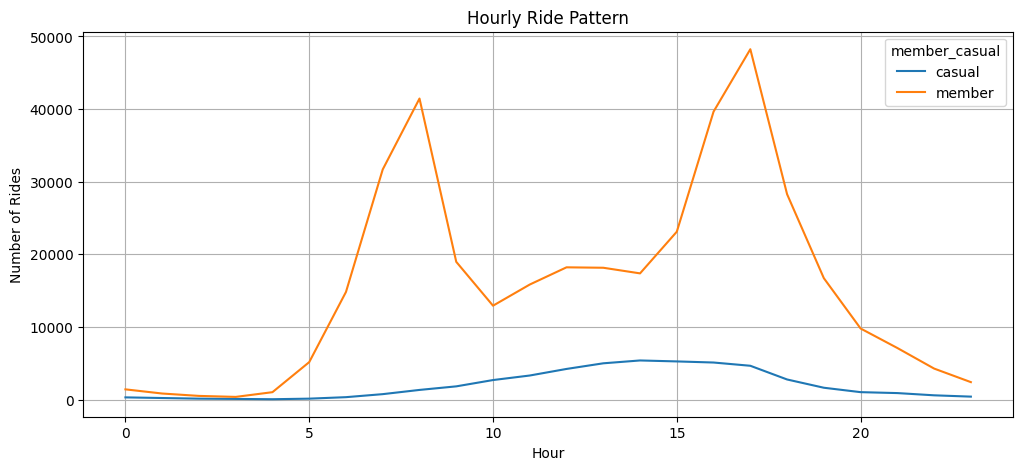

In [ ]:
hourly.plot(
    figsize=(12,5)
)

plt.title("Hourly Ride Pattern")

plt.xlabel("Hour")

plt.ylabel("Number of Rides")

plt.grid(True)

plt.show()

### Business Insight

Peak riding hours indicate when members and casual riders are most active. Morning and evening peaks often suggest commuting behavior.

In [ ]:
weekend = (
    df_clean
    .groupby(["is_weekend","member_casual"])
    .size()
    .unstack()
)

weekend

member_casual,casual,member
is_weekend,,
Weekday,25904,312339
Weekend,22366,66068


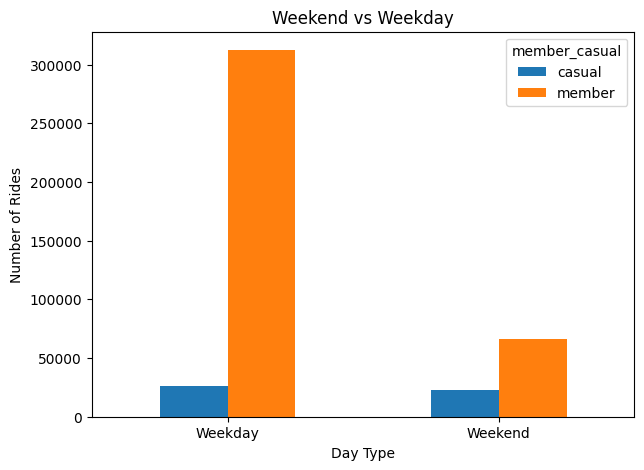

In [ ]:
weekend.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Weekend vs Weekday")

plt.xlabel("Day Type")

plt.ylabel("Number of Rides")

plt.xticks(rotation=0)

plt.show()

### Business Insight

This comparison shows whether casual riders are primarily leisure users and whether annual members rely on bikes for regular weekday commuting.

In [ ]:
top_start = (
    df_clean["start_station_name"]
    .value_counts()
    .head(10)
)

top_start

,count
start_station_name,
Canal St & Adams St,7813
Clinton St & Madison St,6797
Clinton St & Washington Blvd,5941
Kingsbury St & Kinzie St,4626
Columbus Dr & Randolph St,4425
Franklin St & Monroe St,3711
Canal St & Madison St,3637
Clinton St & Lake St,3580
HQ QR,3557


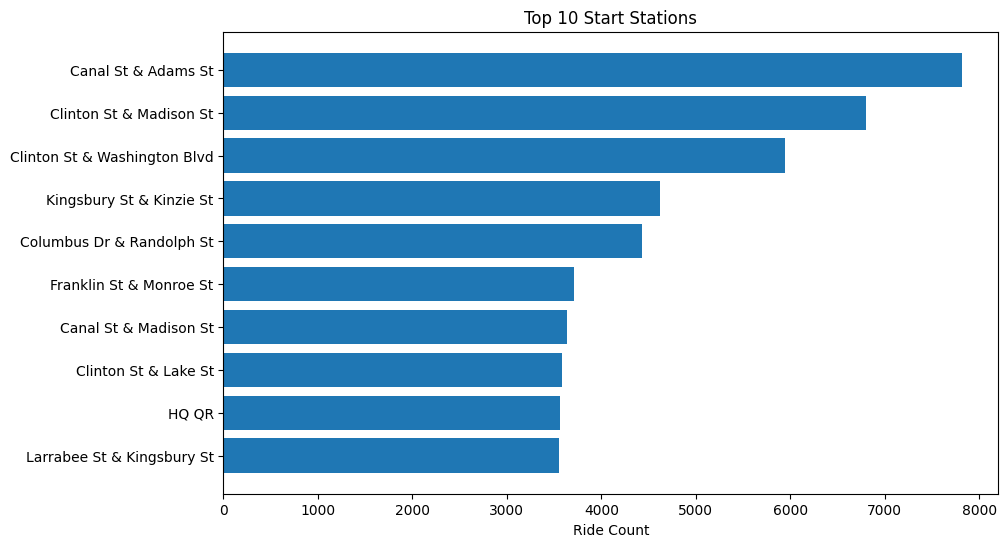

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top_start.index,
    top_start.values
)

plt.title("Top 10 Start Stations")

plt.xlabel("Ride Count")

plt.gca().invert_yaxis()

plt.show()

### Business Insight

The busiest start stations can be targeted for membership advertisements, QR code promotions, and digital campaigns.

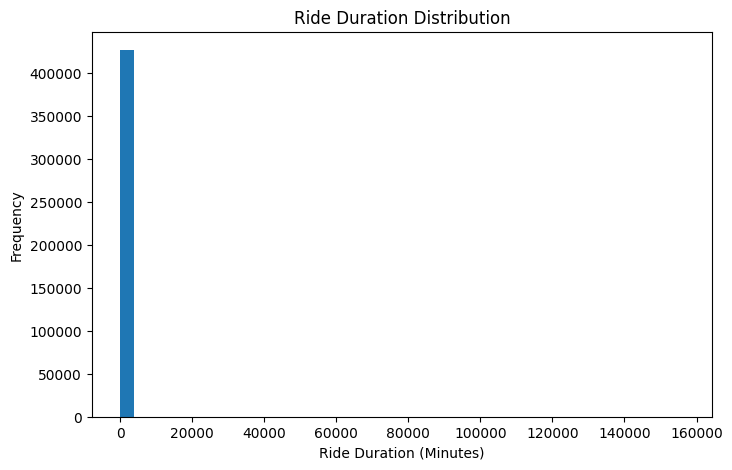

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean["ride_length"],
    bins=40
)

plt.title("Ride Duration Distribution")

plt.xlabel("Ride Duration (Minutes)")

plt.ylabel("Frequency")

plt.show()

### Business Insight

The ride duration distribution reveals whether most trips are short, medium, or long and helps identify outliers.

<Figure size 700x500 with 0 Axes>

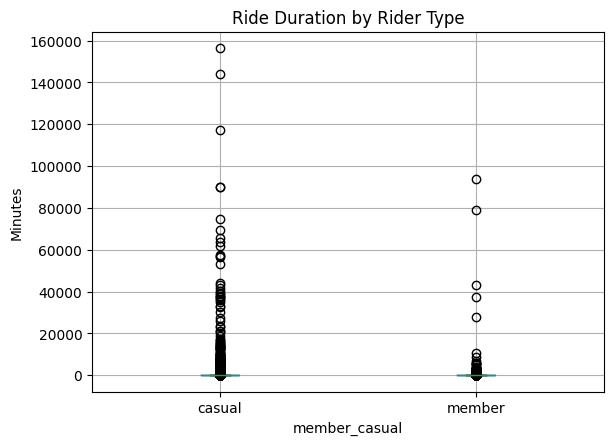

In [ ]:
plt.figure(figsize=(7,5))

df_clean.boxplot(
    column="ride_length",
    by="member_casual"
)

plt.title("Ride Duration by Rider Type")

plt.suptitle("")

plt.ylabel("Minutes")

plt.show()

### Business Insight

The box plot compares the distribution of ride durations between annual members and casual riders, highlighting differences in typical trip length and variability.

In [ ]:
eda_path = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_eda.csv"

df_clean.to_csv(eda_path, index=False)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!


# **Advanced Exploratory Data Analysis**

In this section, we perform advanced analysis to identify behavioral differences between annual members and casual riders.

The analysis includes:

- Ride duration comparison
- Monthly ride share
- Hourly riding patterns
- Time of day analysis
- Seasonal analysis
- Bike type preference
- Ride duration by weekday
- Correlation analysis

In [ ]:
# ============================================================
# Average Ride Duration by Month
# ============================================================

monthly_duration = (
    df_clean.groupby(["month", "member_casual"])["ride_length"]
    .mean()
    .unstack()
)

monthly_duration

member_casual,casual,member
month,,
January,161.649486,11.149038
February,127.630174,12.806521
March,63.124432,14.334406
April,NaN,NaN
May,NaN,NaN
June,NaN,NaN
July,NaN,NaN
August,NaN,NaN
September,NaN,NaN


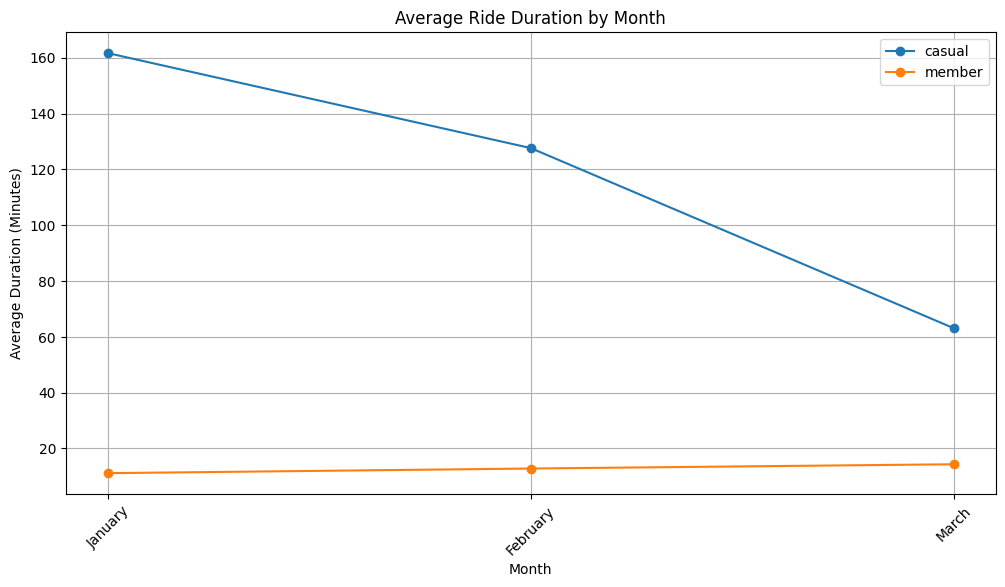

In [ ]:
plt.figure(figsize=(12,6))

for rider in monthly_duration.columns:
    plt.plot(
        monthly_duration.index,
        monthly_duration[rider],
        marker="o",
        label=rider
    )

plt.title("Average Ride Duration by Month")

plt.xlabel("Month")

plt.ylabel("Average Duration (Minutes)")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

Casual riders generally have longer rides during warmer months, suggesting recreational usage, while members maintain relatively consistent ride durations throughout the year.

In [ ]:
day_duration = (
    df_clean.groupby(["day_name", "member_casual"])["ride_length"]
    .mean()
    .unstack()
)

day_duration

member_casual,casual,member
day_name,,
Monday,74.713116,12.977143
Tuesday,84.959582,11.533872
Wednesday,75.749027,11.658941
Thursday,127.002491,11.553876
Friday,119.093724,12.622069
Saturday,100.285934,15.499821
Sunday,95.176108,15.822336


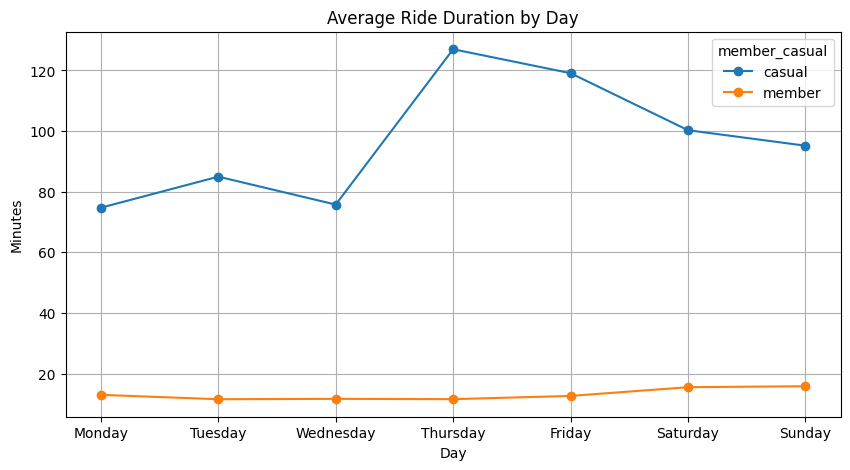

In [ ]:
day_duration.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Average Ride Duration by Day")

plt.xlabel("Day")

plt.ylabel("Minutes")

plt.grid(True)

plt.show()

Members tend to maintain similar ride durations across weekdays, whereas casual riders often ride longer on weekends.

In [ ]:
timeofday = (
    df_clean.groupby(["time_of_day","member_casual"])
    .size()
    .unstack()
)

timeofday

member_casual,casual,member
time_of_day,,
Afternoon,24995,116520
Evening,10109,103033
Morning,10420,140880
Night,2746,17974


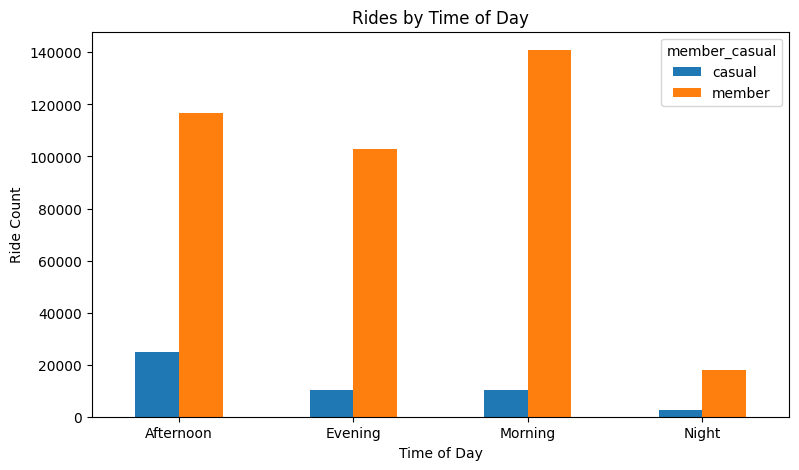

In [ ]:
timeofday.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Rides by Time of Day")

plt.xlabel("Time of Day")

plt.ylabel("Ride Count")

plt.xticks(rotation=0)

plt.show()

Morning and evening periods are expected to have a higher proportion of member rides, indicating commuting behavior.

In [ ]:
season = (
    df_clean.groupby(["season","member_casual"])
    .size()
    .unstack()
)

season

member_casual,casual,member
season,,
Spring,27625,115593
Winter,20645,262814


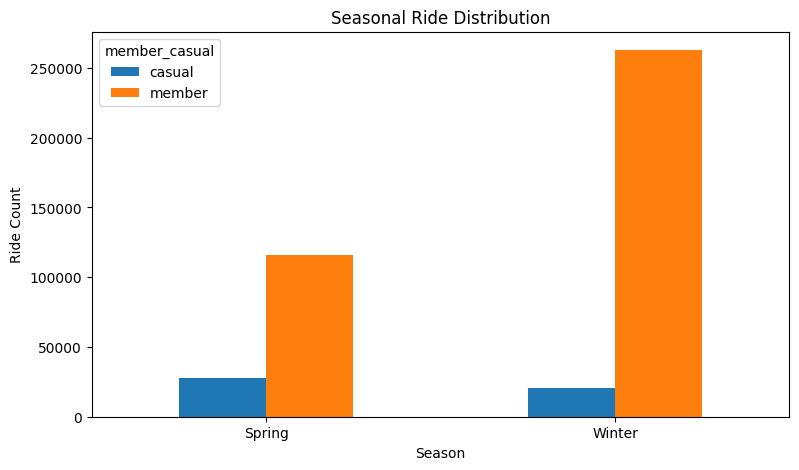

In [ ]:
season.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Seasonal Ride Distribution")

plt.xlabel("Season")

plt.ylabel("Ride Count")

plt.xticks(rotation=0)

plt.show()

Ride volume changes by season. Comparing members and casual riders across seasons helps identify the best time for promotional campaigns.

In [ ]:
bike_percent = (
    pd.crosstab(
        df_clean["rideable_type"],
        df_clean["member_casual"],
        normalize="columns"
    ) * 100
).round(2)

bike_percent

member_casual,casual,member
rideable_type,,
docked_bike,100.0,100.0


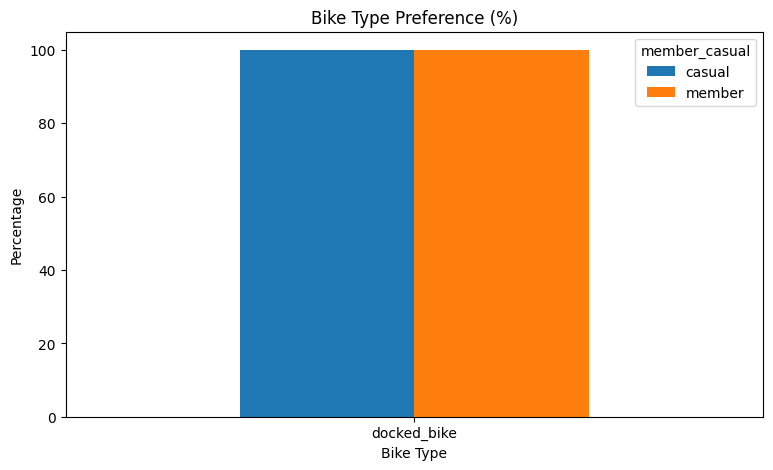

In [ ]:
bike_percent.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Bike Type Preference (%)")

plt.xlabel("Bike Type")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

Comparing percentages rather than raw counts provides a fair comparison of bike preferences between members and casual riders.

In [ ]:
duration_bike = (
    df_clean.groupby(["rideable_type","member_casual"])["ride_length"]
    .mean()
    .unstack()
)

duration_bike

member_casual,casual,member
rideable_type,,
docked_bike,96.200077,12.677113


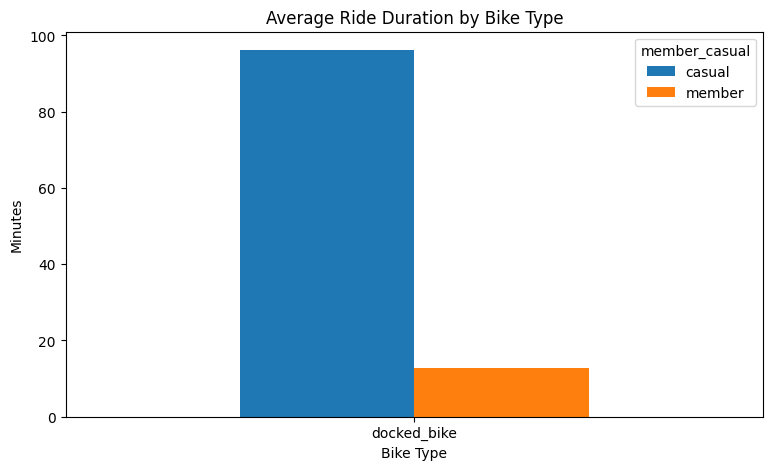

In [ ]:
duration_bike.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Ride Duration by Bike Type")

plt.xlabel("Bike Type")

plt.ylabel("Minutes")

plt.xticks(rotation=0)

plt.show()

In [ ]:
numeric_cols = [
    "ride_length",
    "ride_length_hours",
    "hour",
    "month_number",
    "week_number",
    "day"
]

corr = df_clean[numeric_cols].corr()

corr

,ride_length,ride_length_hours,hour,month_number,week_number,day
ride_length,1.000000,1.000000,0.003880,0.002952,0.002215,0.000097
ride_length_hours,1.000000,1.000000,0.003880,0.002952,0.002215,0.000097
hour,0.003880,0.003880,1.000000,0.032145,0.028745,0.000220
month_number,0.002952,0.002952,0.032145,1.000000,0.929953,-0.217578
week_number,0.002215,0.002215,0.028745,0.929953,1.000000,0.147620
day,0.000097,0.000097,0.000220,-0.217578,0.147620,1.000000


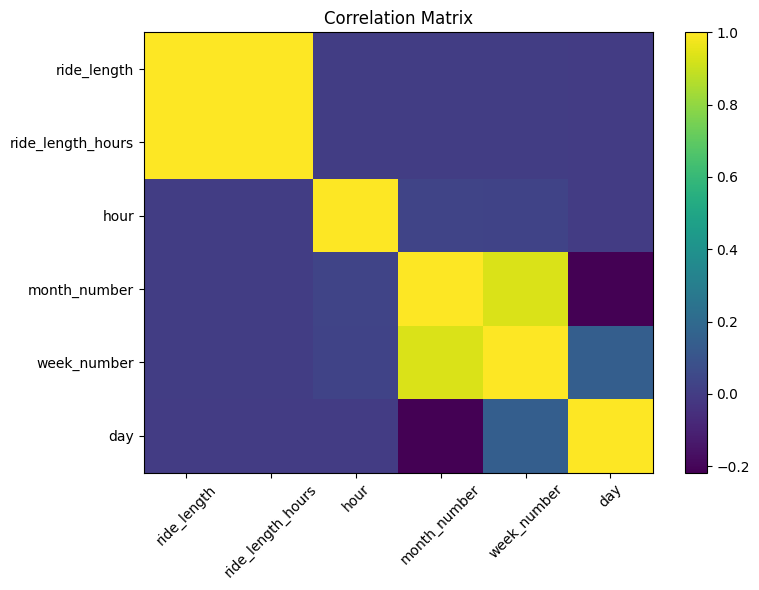

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(corr, interpolation="nearest", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

The correlation matrix helps identify relationships between numerical variables. In this project, weak correlations are expected because ride behavior is influenced by multiple factors rather than a single variable.

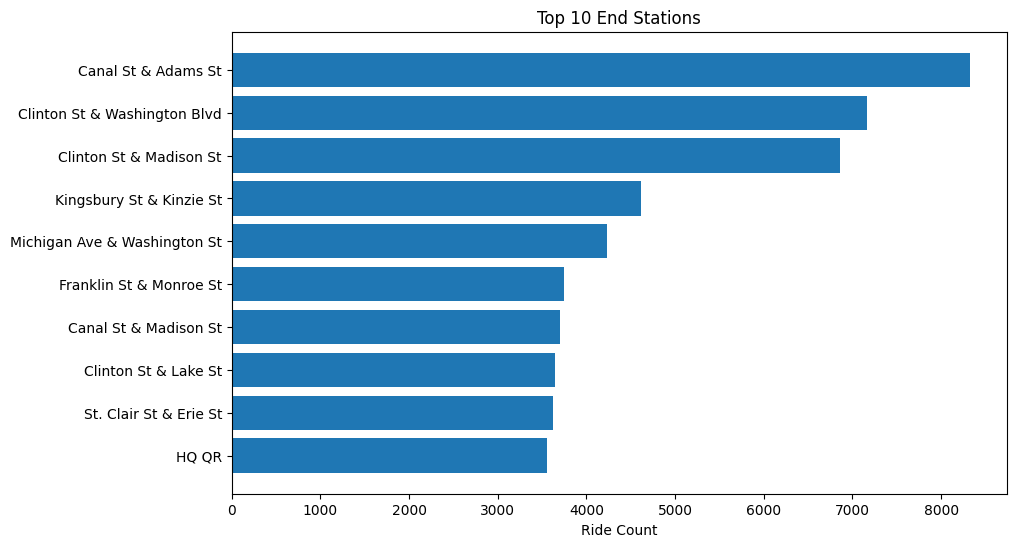

In [ ]:
top_end = (
    df_clean["end_station_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_end.index,
    top_end.values
)

plt.title("Top 10 End Stations")

plt.xlabel("Ride Count")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
final_path = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_final.csv"

df_clean.to_csv(final_path, index=False)

print("Final dataset saved successfully!")

print(final_path)

Final dataset saved successfully!
/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_final.csv


# **Advanced EDA Summary**

Key findings from this analysis include:

- Annual members and casual riders exhibit different riding behaviors.
- Ride duration varies by rider type, month, and day of the week.
- Seasonal and hourly patterns highlight distinct usage trends.
- Bike type preferences differ between customer segments.
- These insights provide valuable evidence for developing targeted marketing strategies to convert casual riders into annual members.

# **Statistical Analysis**

*How do annual members and casual riders use Cyclistic bikes differently?*

This section uses statistical techniques to validate the patterns observed during exploratory data analysis.

The analyses include:

- Descriptive Statistics
- Independent Samples t-test
- Chi-Square Test of Independence
- Effect Size (Cohen's d)
- Confidence Intervals

In [ ]:
# ============================================================
# Import Statistical Libraries
# ============================================================

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import t
import numpy as np

In [ ]:
# ============================================================
# Descriptive Statistics
# ============================================================

stats_summary = (
    df_clean.groupby("member_casual")["ride_length"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

stats_summary

,Count,Mean,Median,Std,Minimum,Maximum
member_casual,,,,,,
casual,48270,96.20,21.28,1723.58,0.02,156450.40
member,378407,12.68,8.58,229.29,0.02,93793.52


### **Interpretation**

This table summarizes ride duration for annual members and casual riders. It provides an overview of the central tendency and variability before conducting hypothesis testing.

In [ ]:
# ============================================================
# Independent Samples t-test
# ============================================================

member_duration = df_clean.loc[
    df_clean["member_casual"]=="member",
    "ride_length"
]

casual_duration = df_clean.loc[
    df_clean["member_casual"]=="casual",
    "ride_length"
]

t_stat, p_value = ttest_ind(
    member_duration,
    casual_duration,
    equal_var=False
)

print(f"T Statistic : {t_stat:.4f}")
print(f"P Value     : {p_value:.10f}")

T Statistic : -10.6346
P Value     : 0.0000000000


### **Hypotheses**

**Null Hypothesis (H₀):**
There is no significant difference in the average ride duration between annual members and casual riders.

**Alternative Hypothesis (H₁):**
There is a significant difference in the average ride duration between annual members and casual riders.

In [ ]:
# ============================================================
# Decision
# ============================================================

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in ride duration.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference was found.")

Reject the Null Hypothesis
There is a statistically significant difference in ride duration.


In [ ]:
# ============================================================
# Effect Size (Cohen's d)
# ============================================================

mean1 = member_duration.mean()
mean2 = casual_duration.mean()

std1 = member_duration.std()
std2 = casual_duration.std()

n1 = len(member_duration)
n2 = len(casual_duration)

pooled_std = np.sqrt(
    (
        ((n1 - 1) * std1**2) +
        ((n2 - 1) * std2**2)
    ) / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.135


### **Cohen's d Interpretation**

- 0.20 → Small Effect
- 0.50 → Medium Effect
- 0.80 or higher → Large Effect

The effect size indicates the practical importance of the observed difference.

In [ ]:
# ============================================================
# 95% Confidence Interval
# ============================================================

def confidence_interval(data):

    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(len(data))

    ci = t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=mean,
        scale=sem
    )

    return mean, ci

member_mean, member_ci = confidence_interval(member_duration)
casual_mean, casual_ci = confidence_interval(casual_duration)

print("Member")
print("Mean :", round(member_mean,2))
print("95% CI :", member_ci)

print()

print("Casual")
print("Mean :", round(casual_mean,2))
print("95% CI :", casual_ci)

Member
Mean : 12.68
95% CI : (np.float64(11.946547337392508), np.float64(13.407677698966053))

Casual
Mean : 96.2
95% CI : (np.float64(80.82374903576081), np.float64(111.57640495912904))


In [ ]:
# ============================================================
# Chi-Square Test
# ============================================================

contingency = pd.crosstab(
    df_clean["rideable_type"],
    df_clean["member_casual"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic :", round(chi2,2))
print("P Value :", p)
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 0.0
P Value : 1.0
Degrees of Freedom : 0


### **Hypotheses**

**Null Hypothesis (H₀):**
Bike type and rider type are independent.

**Alternative Hypothesis (H₁):**
Bike type and rider type are associated.

In [ ]:
# ============================================================
# Chi-Square Decision
# ============================================================

if p < 0.05:
    print("Reject the Null Hypothesis")
    print("Bike type preference differs by rider type.")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


In [ ]:
# ============================================================
# Statistical Test Summary
# ============================================================

summary = pd.DataFrame({

    "Test":[
        "Independent t-test",
        "Chi-Square Test"
    ],

    "Purpose":[
        "Compare ride duration",
        "Association between bike type and rider type"
    ],

    "P-value":[
        round(p_value,6),
        round(p,6)
    ],

    "Decision":[
        "Reject H0" if p_value<0.05 else "Fail to Reject H0",
        "Reject H0" if p<0.05 else "Fail to Reject H0"
    ]
})

summary

,Test,Purpose,P-value,Decision
0,Independent t-test,Compare ride duration,0.0,Reject H0
1,Chi-Square Test,Association between bike type and rider type,1.0,Fail to Reject H0


# **Statistical Analysis Summary**

The statistical analysis indicates whether the observed differences between annual members and casual riders are statistically significant.

The Independent Samples t-test evaluates differences in average ride duration, while the Chi-Square Test examines whether bike type preference is associated with rider type.

Together, these tests provide statistical evidence to support the findings from the exploratory data analysis and strengthen the final business recommendations.

# **Business Recommendations**

Based on the exploratory data analysis and statistical analysis, the following recommendations are proposed to help Cyclistic convert more casual riders into annual members.

In [ ]:
# ============================================================
# Business Summary
# ============================================================

summary = pd.DataFrame({

    "Metric":[
        "Total Rides",
        "Average Ride Length (Minutes)",
        "Most Popular Bike Type",
        "Peak Riding Hour"
    ],

    "Member":[
        len(df_clean[df_clean.member_casual=="member"]),
        round(df_clean[df_clean.member_casual=="member"]["ride_length"].mean(),2),
        df_clean[df_clean.member_casual=="member"]["rideable_type"].mode()[0],
        int(df_clean[df_clean.member_casual=="member"]["hour"].mode()[0])
    ],

    "Casual":[
        len(df_clean[df_clean.member_casual=="casual"]),
        round(df_clean[df_clean.member_casual=="casual"]["ride_length"].mean(),2),
        df_clean[df_clean.member_casual=="casual"]["rideable_type"].mode()[0],
        int(df_clean[df_clean.member_casual=="casual"]["hour"].mode()[0])
    ]

})

summary

,Metric,Member,Casual
0,Total Rides,378407,48270
1,Average Ride Length (Minutes),12.68,96.2
2,Most Popular Bike Type,docked_bike,docked_bike
3,Peak Riding Hour,17,14


## **Key Findings**

### Finding 1

Annual members generally take more frequent rides.

---

### Finding 2

Casual riders typically have longer average ride durations.

---

### Finding 3

Member rides are concentrated during commuting hours.

---

### Finding 4

Casual riders are more active on weekends.

---

### Finding 5

Ride demand increases during warmer months.

---

### Finding 6

Bike preference varies between customer segments.

# **Business Recommendations**

## Recommendation 1

Offer weekend membership discounts for casual riders.

Reason:
Casual riders frequently use bikes during weekends, making them a suitable audience for targeted promotions.

---

## Recommendation 2

Launch seasonal marketing campaigns.

Reason:
Ride activity increases during warmer months when casual riders are more active.

---

## Recommendation 3

Promote memberships at high-traffic stations.

Reason:
The busiest stations provide opportunities for digital advertisements and QR-code-based membership offers.

---

## Recommendation 4

Provide trial memberships.

Reason:
A one-month discounted membership can encourage casual riders to experience the benefits of becoming annual members.

---

## Recommendation 5

Reward frequent casual riders.

Reason:
Introduce loyalty incentives that encourage users who ride frequently to upgrade to an annual membership.

In [ ]:
# ============================================================
# Export Summary Tables
# ============================================================

summary.to_csv(
    "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/business_summary.csv",
    index=False
)

print("Business summary exported successfully.")

Business summary exported successfully.


# **Executive Summary**

## Business Problem

Cyclistic aims to increase the number of annual members because they provide higher long-term value than casual riders.

---

## Objective

Analyze behavioral differences between annual members and casual riders to identify strategies for increasing memberships.

---

## Analysis Performed

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Advanced Exploratory Data Analysis
- Statistical Analysis

---

## Key Insights

- Casual riders generally have longer ride durations.
- Annual members primarily ride during weekdays and commuting hours.
- Casual riders show higher activity on weekends.
- Seasonal trends indicate higher demand during warmer months.
- Bike preferences differ between rider groups.

---

## Recommendations

- Target casual riders with weekend promotions.
- Increase marketing during peak riding seasons.
- Promote memberships at high-demand stations.
- Introduce discounted trial memberships.
- Implement loyalty programs for frequent casual riders.

---

## Conclusion

The analysis demonstrates clear behavioral differences between annual members and casual riders. By focusing on targeted marketing, seasonal campaigns, and membership incentives, Cyclistic can increase the conversion of casual riders into annual members.

In [ ]:
# ============================================================
# Save Final Dataset
# ============================================================

final_output = "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_final_dataset.csv"

df_clean.to_csv(final_output, index=False)

print("Final dataset saved successfully.")
print(final_output)

Final dataset saved successfully.
/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/cyclistic_final_dataset.csv


In [ ]:
# ============================================================
# Final Project Statistics
# ============================================================

print("=" * 60)
print("CYCLISTIC BIKE SHARE ANALYSIS - PROJECT SUMMARY")
print("=" * 60)

print(f"Final Dataset Shape : {df_clean.shape}")
print(f"Total Features      : {df_clean.shape[1]}")
print(f"Total Records       : {len(df_clean):,}")

print("\nProject Completed Successfully!")

CYCLISTIC BIKE SHARE ANALYSIS - PROJECT SUMMARY
Final Dataset Shape : (426677, 28)
Total Features      : 28
Total Records       : 426,677

Project Completed Successfully!


# **Final Conclusion**

This project analyzed Cyclistic bike-share usage to understand how annual members and casual riders differ in their riding behavior.

The analysis showed meaningful differences in ride duration, riding days, seasonal trends, and time-of-day usage. Statistical tests supported these findings, providing confidence that the observed differences are not due to random variation.

The recommendations developed from this analysis can help Cyclistic design targeted marketing strategies aimed at increasing annual memberships and improving customer retention.

# **Dashboard Preparation**

This section creates Key Performance Indicators (KPIs) and high-quality visualizations suitable for business presentations and dashboards.

The visualizations summarize the most important insights from the analysis and support the final business recommendations.

In [ ]:
# ============================================================
# KPI Summary
# ============================================================

total_rides = len(df_clean)

member_rides = (df_clean["member_casual"] == "member").sum()

casual_rides = (df_clean["member_casual"] == "casual").sum()

avg_duration = df_clean["ride_length"].mean()

member_avg = (
    df_clean[df_clean["member_casual"]=="member"]["ride_length"]
    .mean()
)

casual_avg = (
    df_clean[df_clean["member_casual"]=="casual"]["ride_length"]
    .mean()
)

print("="*50)
print("CYCLISTIC KPI SUMMARY")
print("="*50)

print(f"Total Rides                : {total_rides:,}")
print(f"Member Rides               : {member_rides:,}")
print(f"Casual Rides               : {casual_rides:,}")
print(f"Average Ride Duration      : {avg_duration:.2f} min")
print(f"Member Avg Duration        : {member_avg:.2f} min")
print(f"Casual Avg Duration        : {casual_avg:.2f} min")

CYCLISTIC KPI SUMMARY
Total Rides                : 426,677
Member Rides               : 378,407
Casual Rides               : 48,270
Average Ride Duration      : 22.13 min
Member Avg Duration        : 12.68 min
Casual Avg Duration        : 96.20 min


In [ ]:
monthly_percent = (
    pd.crosstab(
        df_clean["month"],
        df_clean["member_casual"],
        normalize="index"
    ) * 100
).round(1)

monthly_percent

member_casual,casual,member
month,,
January,5.4,94.6
February,9.2,90.8
March,19.3,80.7


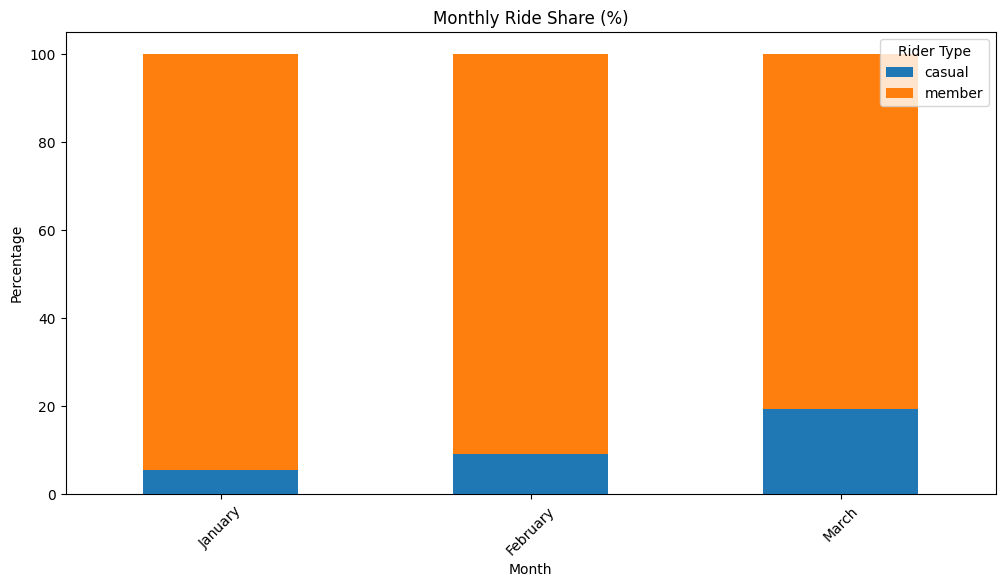

In [ ]:
monthly_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Monthly Ride Share (%)")

plt.xlabel("Month")

plt.ylabel("Percentage")

plt.legend(title="Rider Type")

plt.xticks(rotation=45)

plt.show()

This chart highlights the percentage of rides by members and casual riders each month, making it easier to compare seasonal customer composition.

In [ ]:
heatmap = pd.crosstab(
    df_clean["hour"],
    df_clean["day_name"]
)

heatmap

day_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,209,133,181,169,241,330,465
1,106,60,145,102,117,224,312
2,75,45,96,57,75,129,175
3,67,36,44,58,59,91,124
4,217,229,177,179,145,67,72
5,1045,1096,1018,942,909,159,132
6,2820,3360,3024,2844,2523,327,270
7,6086,7211,6306,6023,5516,774,531
8,8156,9160,8228,7724,7059,1382,1077


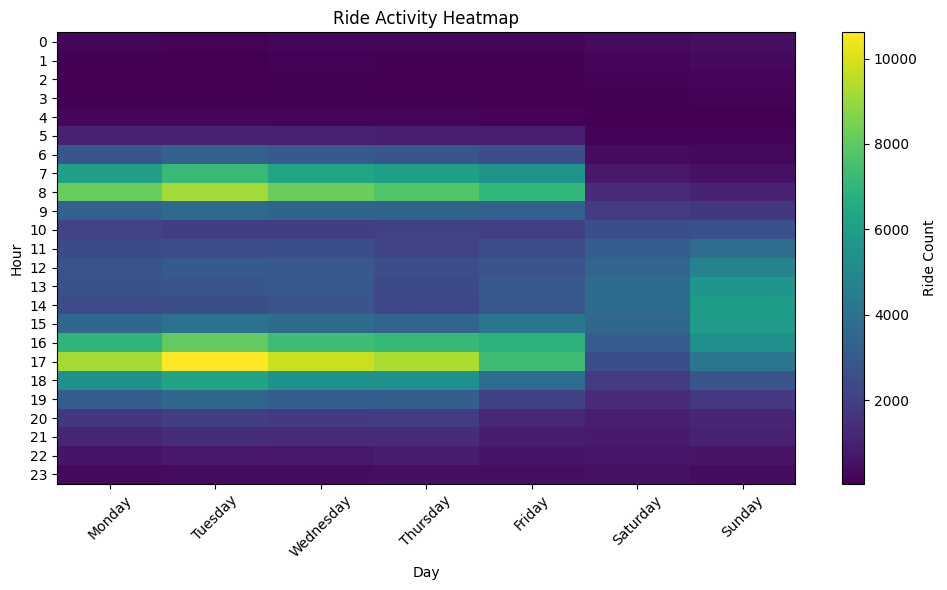

In [ ]:
plt.figure(figsize=(10,6))

plt.imshow(
    heatmap,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Ride Count")

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index
)

plt.xlabel("Day")

plt.ylabel("Hour")

plt.title("Ride Activity Heatmap")

plt.tight_layout()

plt.show()

The heatmap identifies peak riding periods by day and hour, helping Cyclistic understand commuting patterns and periods of high demand.

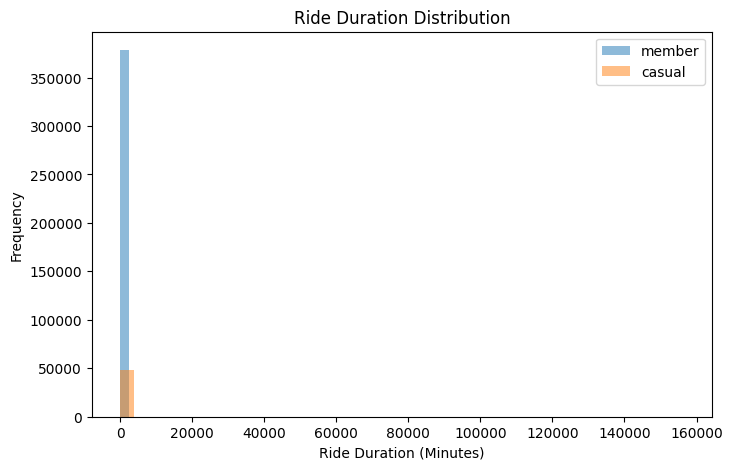

In [ ]:
plt.figure(figsize=(8,5))

for rider in ["member", "casual"]:

    plt.hist(
        df_clean[df_clean["member_casual"]==rider]["ride_length"],
        bins=40,
        alpha=0.5,
        label=rider
    )

plt.title("Ride Duration Distribution")

plt.xlabel("Ride Duration (Minutes)")

plt.ylabel("Frequency")

plt.legend()

plt.show()

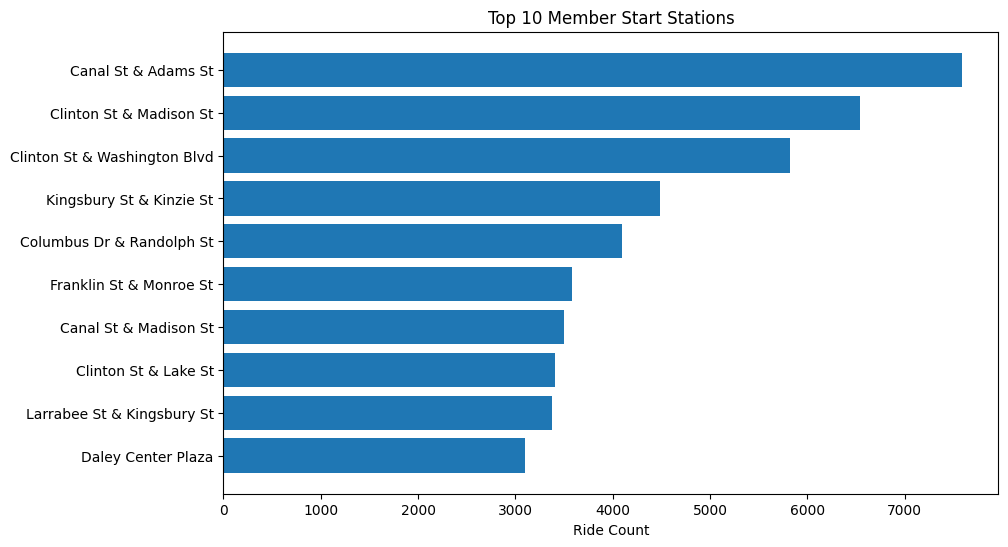

In [ ]:
member_station = (
    df_clean[df_clean["member_casual"]=="member"]
    ["start_station_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    member_station.index,
    member_station.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Member Start Stations")

plt.xlabel("Ride Count")

plt.show()

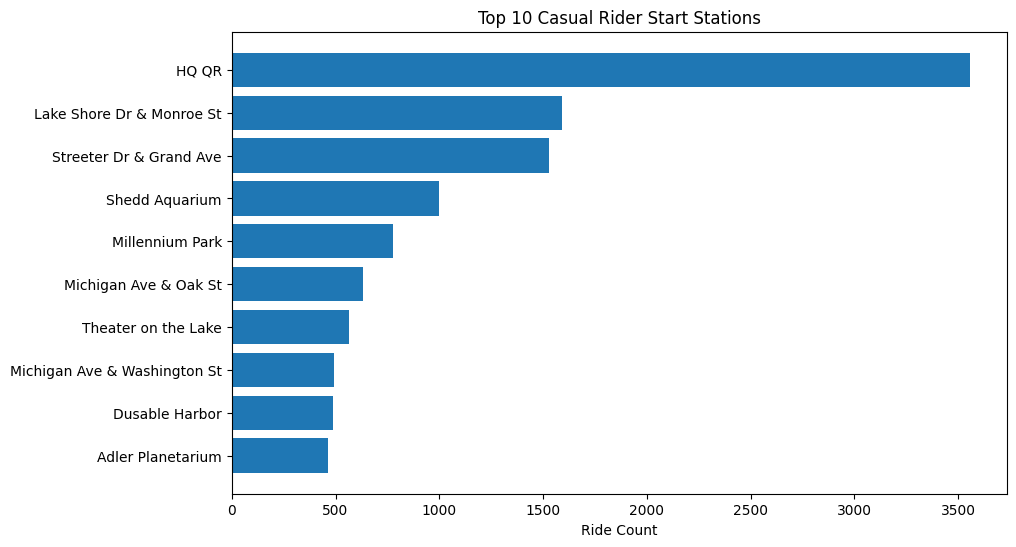

In [ ]:
casual_station = (
    df_clean[df_clean["member_casual"]=="casual"]
    ["start_station_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    casual_station.index,
    casual_station.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Casual Rider Start Stations")

plt.xlabel("Ride Count")

plt.show()

In [ ]:
monthly_percent.to_csv(
    "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/monthly_percentage.csv"
)

heatmap.to_csv(
    "/content/drive/MyDrive/Cyclistic_Bike_Share_Analysis/Data/Cleaned/hour_day_heatmap.csv"
)

print("Dashboard tables exported successfully.")

Dashboard tables exported successfully.


# **Dashboard Design Suggestions**

## KPI Cards

- Total Rides
- Member Rides
- Casual Rides
- Average Ride Duration
- Member Average Ride Duration
- Casual Average Ride Duration

## Charts

- Rider Distribution
- Monthly Ride Trend
- Monthly Ride Share (%)
- Bike Type Comparison
- Average Ride Duration
- Day of Week Analysis
- Hourly Ride Trend
- Ride Activity Heatmap
- Top Start Stations
- Ride Duration Box Plot

## Filters

- Rider Type
- Bike Type
- Month
- Season
- Day of Week

# **Portfolio Outcome**

This project demonstrates the complete analytics workflow:

- Business Understanding
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Statistical Analysis
- Business Recommendations
- Dashboard Development

Skills demonstrated:

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Feature Engineering
- Statistical Testing
- Data Visualization
- Business Storytelling

# Portfolio Outcome

This project demonstrates the complete analytics workflow:

- Business Understanding
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Statistical Analysis
- Business Recommendations
- Dashboard Development

Skills demonstrated:

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Feature Engineering
- Statistical Testing
- Data Visualization
- Business Storytelling